In [1]:
import numpy as np
print(np.__version__)

2.4.6


In [2]:
%pip install pymc


Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
print(np.__version__)

2.4.6


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import joblib
from pathlib import Path

ROOT        = Path('..')
RBI_PATH    = ROOT / 'data' / 'processed' / 'rbi_labels.csv'
MODELS_DIR  = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_rbi = pd.read_csv(RBI_PATH)
last = df_rbi.sort_values(['line_id','year','quarter'])\
             .groupby('line_id').last().reset_index()

print(f'✅ Setup completo')
print(f'   PyMC  : {pm.__version__}')
print(f'   Activos: {len(last)}')
print(last[['line_id','pof_category','pof_raw','cr_mean','RUL_years','risk_label']]\
      .to_string(index=False))

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✅ Setup completo
   PyMC  : 5.28.5
   Activos: 12
line_id  pof_category  pof_raw  cr_mean  RUL_years risk_label
  E-101             3 0.000556  0.28093       6.95       High
   L-01             5 0.002505  0.28350       0.31   Critical
   L-02             5 0.003425  0.29430       0.05   Critical
   L-03             5 0.004427  0.54867       0.07   Critical
   L-04             3 0.000730  0.12100       6.13     Medium
   L-05             4 0.001096  0.16123       3.56       High
   L-06             4 0.000960  0.13960       5.05     Medium
   L-07             2 0.000292  0.05860      36.64     Medium
   L-08             3 0.000768  0.08300      17.41       High
   L-09             2 0.000125  0.05050      55.63        Low
   L-10             5 0.007415  0.70578       0.02   Critical
  V-101             3 0.000719  0.41850      10.96       High


In [5]:
def run_living_rbi(row: pd.Series, samples: int = 2000) -> dict:
    tag     = row['line_id']
    pof_rf  = float(row['pof_raw'])
    cr      = float(row['cr_mean'])
    rul     = float(row['RUL_years'])

    concentration = 10.0
    alpha_prior = max(pof_rf * concentration, 0.01)
    beta_prior  = max((1 - pof_rf) * concentration, 0.01)

    cr_threshold = 0.20
    n_obs        = 10
    k_failures   = min(int((cr / cr_threshold) * n_obs * 0.5), n_obs)

    with pm.Model() as model:
        pof = pm.Beta('pof', alpha=alpha_prior, beta=beta_prior)
        obs = pm.Binomial('obs', n=n_obs, p=pof, observed=k_failures)
        trace = pm.sample(samples, tune=1000, chains=2,
                         progressbar=False, random_seed=42,
                         return_inferencedata=True)

    pof_post     = trace.posterior['pof'].values.flatten()
    pof_mean     = float(pof_post.mean())
    pof_hdi_low  = float(np.percentile(pof_post, 5))
    pof_hdi_high = float(np.percentile(pof_post, 95))

    if pof_mean > 0.5 or rul < 0.5:
        insp_interval = 3
    elif pof_mean > 0.2 or rul < 2.0:
        insp_interval = 6
    elif pof_mean > 0.05 or rul < 5.0:
        insp_interval = 12
    else:
        insp_interval = 24

    return {
        'tag'             : tag,
        'pof_prior'       : round(pof_rf, 6),
        'pof_posterior'   : round(pof_mean, 6),
        'pof_hdi_5'       : round(pof_hdi_low, 6),
        'pof_hdi_95'      : round(pof_hdi_high, 6),
        'pof_update'      : round(pof_mean - pof_rf, 6),
        'cr_mean'         : round(cr, 4),
        'RUL_years'       : round(rul, 2),
        'insp_interval_mo': insp_interval,
        'risk_label'      : row['risk_label'],
        'trace'           : trace,
    }

print('Corriendo Living RBI Bayesiano...')
results = {}
for _, row in last.iterrows():
    print(f'  Procesando {row["line_id"]}...', end=' ')
    results[row['line_id']] = run_living_rbi(row)
    print(f'✅  PoF posterior: {results[row["line_id"]]["pof_posterior"]:.4f}')

print(f'\n✅ Living RBI completado — {len(results)} activos')

Initializing NUTS using jitter+adapt_diag...


Corriendo Living RBI Bayesiano...
  Procesando E-101... 

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pof]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


✅  PoF posterior: 0.3480
  Procesando L-01... 

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pof]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


...

✅  PoF posterior: 0.0524
  Procesando L-10... 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pof]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...


✅  PoF posterior: 0.5063
  Procesando V-101... 

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [pof]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


✅  PoF posterior: 0.5048

✅ Living RBI completado — 12 activos


In [6]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'trace'}
    for r in results.values()
])

print('='*75)
print('LIVING RBI BAYESIANO — Resultados por activo')
print('='*75)
print(df_results[['tag','pof_prior','pof_posterior','pof_update',
                   'cr_mean','RUL_years','insp_interval_mo',
                   'risk_label']].to_string(index=False))

LIVING RBI BAYESIANO — Resultados por activo
  tag  pof_prior  pof_posterior  pof_update  cr_mean  RUL_years  insp_interval_mo risk_label
E-101   0.000556       0.347967    0.347410   0.2809       6.95                 6       High
 L-01   0.002505       0.349313    0.346808   0.2835       0.31                 3   Critical
 L-02   0.003425       0.354239    0.350815   0.2943       0.05                 3   Critical
 L-03   0.004427       0.500742    0.496315   0.5487       0.07                 3   Critical
 L-04   0.000730       0.149654    0.148924   0.1210       6.13                12     Medium
 L-05   0.001096       0.198825    0.197729   0.1612       3.56                12       High
 L-06   0.000960       0.151615    0.150655   0.1396       5.05                12     Medium
 L-07   0.000292       0.051357    0.051065   0.0586      36.64                12     Medium
 L-08   0.000768       0.099333    0.098566   0.0830      17.41                12       High
 L-09   0.000125       0.

In [7]:
RESULTS_OUT = ROOT / 'data' / 'processed' / 'living_rbi_results.csv'
df_save = df_results.drop(columns=['trace'] if 'trace' in df_results.columns else [])
df_save.to_csv(RESULTS_OUT, index=False)
print(f'✅ Resultados guardados: {RESULTS_OUT}')

✅ Resultados guardados: ..\data\processed\living_rbi_results.csv


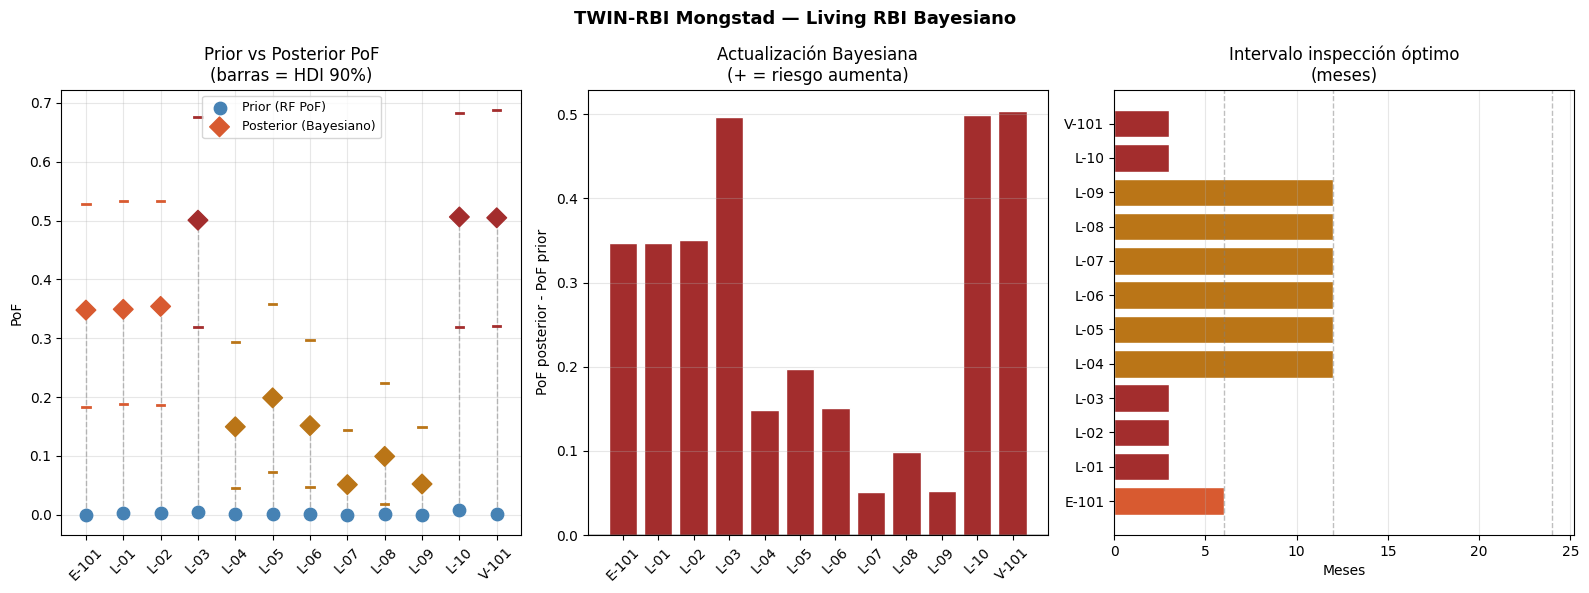

💾 fig_living_rbi.png guardada


In [ ]:
# ── Figura Living RBI ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

tags      = df_results['tag'].tolist()
prior     = df_results['pof_prior'].values
posterior = df_results['pof_posterior'].values
hdi_low   = df_results['pof_hdi_5'].values
hdi_high  = df_results['pof_hdi_95'].values
intervals = df_results['insp_interval_mo'].values

x = np.arange(len(tags))
colors = ['#A32D2D' if p > 0.4 else '#D85A30' if p > 0.2
          else '#BA7517' if p > 0.05 else '#1D9E75'
          for p in posterior]

# ── 1. Prior vs Posterior ─────────────────────────────────
axes[0].scatter(x, prior,     color='steelblue', s=80,
                zorder=3, label='Prior (RF PoF)')
axes[0].scatter(x, posterior, color=colors, s=100,
                zorder=3, label='Posterior (Bayesiano)', marker='D')
for i in range(len(tags)):
    axes[0].plot([x[i], x[i]], [prior[i], posterior[i]],
                 color='gray', lw=1, ls='--', alpha=0.5)
    axes[0].plot([x[i]-0.1, x[i]+0.1],
                 [hdi_low[i], hdi_low[i]], color=colors[i], lw=2)
    axes[0].plot([x[i]-0.1, x[i]+0.1],
                 [hdi_high[i], hdi_high[i]], color=colors[i], lw=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tags, rotation=45)
axes[0].set_ylabel('PoF')
axes[0].set_title('Prior vs Posterior PoF\n(barras = HDI 90%)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── 2. Actualización bayesiana (delta) ────────────────────
delta = posterior - prior
bar_colors = ['#A32D2D' if d > 0 else '#1D9E75' for d in delta]
axes[1].bar(tags, delta, color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xticklabels(tags, rotation=45)
axes[1].set_ylabel('PoF posterior - PoF prior')
axes[1].set_title('Actualización Bayesiana\n(+ = riesgo aumenta)')
axes[1].grid(True, alpha=0.3, axis='y')

# ── 3. Intervalo de inspección óptimo ─────────────────────
insp_colors = ['#A32D2D' if i<=3 else '#D85A30' if i<=6
               else '#BA7517' if i<=12 else '#1D9E75'
               for i in intervals]
axes[2].barh(tags, intervals, color=insp_colors, edgecolor='white')
axes[2].axvline(6,  color='gray', lw=1, ls='--', alpha=0.5)
axes[2].axvline(12, color='gray', lw=1, ls='--', alpha=0.5)
axes[2].axvline(24, color='gray', lw=1, ls='--', alpha=0.5)
axes[2].set_xlabel('Meses')
axes[2].set_title('Intervalo inspección óptimo\n(meses)')
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('TWIN-RBI Mongstad — Living RBI Bayesiano',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_living_rbi.png', bbox_inches='tight')
plt.show()
print('fig_living_rbi.png guardada')